# PLANTEAMIENTO DEL PROBLEMA

Una compañia de telecomunicaciones tiene un enorme inconveniente para poder atender sus reclamos por tickets de fallas cuando ocurre un caso masivo, se satura la bandeja de entrada y no se le brinda la atencion rapida al cliente lo que causa molestia por los largos tiempos de espera que tienen que padecer los clientes para poder ser atendidos por soporte tecnico.

# SOLUCION

SE NECESITA UN ALGORITMO DE MACHINE LEARNING (IA) QUE PUEDA DETECTAR Y CLASIFICAR LOS CASOS DE FALLAS MASIVAS Y CASOS DE FALLAS PUNTUALES, EN TIEMPO REAL. PARA ESTO TOMANDO EN CONSIDERACION UNA TABLA DE DATOS EN EXCEL EN FORMATO CSV CON 1000 EJEMPLOS DIFERENTES DE TODAS LAS CARACTERISTICAS QUE SE TOMAN EN CUENTA PARA CLASIFICAR UNA FALLA COMO MASIVA Y OTRA COMO PUNTUAL Y DE ESTA FORMA NO SATURAR LA BANDEJA DE ENTRADA Y SOLVENTAR LOS CASOS MASIVOS EN OTRA BANDEJA APARTE O AUTOMATICAMENTE. ADICIONAL A ELLO EL ALGORITMO DE MACHINE LEARNING SERA CAPAZ DE PREDECIR CUANDO SE PODRIA PRESENTAR UNA FALLA MASIVA EN EL FUTURO.

# INICIEMOS LA CONSTRUCION DEL CEREBRO DE ESTE ALGORITMO CLASIFICADOR DE FALLAS MASIVAS

In [6]:
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import matplotlib.gridspec as gridspec
from collections import Counter
from sklearn import metrics
import numpy as np
from sklearn.model_selection import train_test_split
from matplotlib.colors import LogNorm
from sklearn.metrics import f1_score

#lectura del conjunto de datos fallas/telecom
df = pd.read_csv("/content/fallas_telecom_1000 - fallas_telecom_1000.csv")

df.head(1000)

,OLT,Tarjeta,Puerto,Clientes afectados,Hora de afectación,CLASE
0,mbo-bvis-olt-03,1,8,16,10:58 a.m.,Masivo
1,mbo-bvis-olt-05,2,12,5,12:00 am,Puntual
2,mbo-lpue-olt-00,1,0,8,4:50 am,Masivo
3,mbo-call-olt-05,1,0,40,3:26 pm,Masivo
4,mbo-lpue-olt-00,1,3,2,1:52 pm,Puntual
...,...,...,...,...,...,...
995,flc-coro-olt-04,7,6,23,4:43 pm,Masivo
996,flc-coro-olt-04,3,6,2,2:54 am,Puntual
997,mbo-lpue-olt-00,2,3,1,3:07 a.m.,Puntual
998,mbo-lpue-olt-00,7,12,10,9:36 am,Masivo


IMPORTANDO TODAS LAS LIBRERIAS QUE NECESITAMOS Y LA TABLA DE DATOS DE NUESTRO DATA SET, AHORA TOCA VECTORIZAR EL DATASET

In [7]:

#creamos una funcion que separe el df en 3 sub conjuntos diferentes
#train_set 60%, val_set 20% test_set 20%
#funciones auxiliares
def train_val_test_split(df, rstate=42, shuffle=True, stratify=None):
    strat = df[stratify] if stratify is not None else None
    train_set, test_set = train_test_split(
        df, test_size=0.4, random_state=rstate, shuffle=shuffle, stratify=strat)
    strat = test_set[stratify] if stratify is not None else None
    val_set, test_set = train_test_split(
        test_set, test_size=0.5, random_state=rstate, shuffle=shuffle, stratify=strat)
    return (train_set, val_set, test_set)



In [8]:
train_set, val_set, test_set = train_val_test_split(df, stratify='CLASE')

En la parte de codigo de arriba creamos una funcion que hace el particionado del conjunto de datos, y los guarda en las variables set de entrenamiento, set de validacion y set de pruebas.

In [9]:

#imprimimos los % de cada subconjunto esto se hace para entrenar mejor el algoritmo
print("Longitud del Training Set:", len(train_set))
print("Longitud del Validation Set:", len(val_set))
print("Longitud del Test Set:", len(test_set))

#observamos si tenemos datos nulos y object que es (categoricos pues letras)
df.info()

Longitud del Training Set: 600
Longitud del Validation Set: 200
Longitud del Test Set: 200
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   OLT                 1000 non-null   object
 1   Tarjeta             1000 non-null   int64 
 2   Puerto              1000 non-null   int64 
 3   Clientes afectados  1000 non-null   int64 
 4   Hora de afectación  1000 non-null   object
 5   CLASE               1000 non-null   object
dtypes: int64(3), object(3)
memory usage: 47.0+ KB


observamos la longuitud de los datos guardados. para entrenar el algoritmo tenemos 600 ejemplos y la validacion del algoritmo son 200 y para probar el algoritmo son 200




AHORA PARA UTILIZAR ALGUN ALGORITMO PREDICTIVO ES NECESARIO QUE EL CONJUNTO DE DATOS NO TENGA DATOS CATEGORICOS NI DATOS NULOS.

ESTO SUCEDE PORQUE EL ALGORITMO PREDICTIVO SOLO ENTIENDE DE NUMEROS NO DE LETRAS. POR TANTO HAY QUE TRANSFORMAR EL CONJUNTO DE DATOS CON UNA TUBERIA (PIPELINE) PARA LIMPIAR ESTOS DATOS CON LA TECNICA ONE HOT ENCODED

No necesariamente se utilizan las mismas transformaciones cada columna por eso separamos el conjunto de datos en X , Y donde X son las caracteristicas, y Es la estiqueta final en base a las caracteristicas.

In [15]:
#Separemos las etiquetas para tener el conjunto de datos limpio
#definir el x,y Del conjunto de datos
X_train = train_set.drop("CLASE", axis=1)
y_train = train_set["CLASE"]



In [21]:
#PARA UTILIZAR SVM NECESITAMOS X, Y de cada division
X_val = val_set.drop("CLASE", axis=1)
y_val = val_set["CLASE"]

X_test = test_set.drop("CLASE", axis=1)
y_test = test_set["CLASE"]

In [11]:
y_train.value_counts()
#conjunto de datos desnivelado levemente, al definir nuestras clases

,count
CLASE,
Masivo,353
Puntual,247


PARA ESTE CONJUNTO DE 1000 DATOS DE FALLAS OBSERVAMOS QUE 353 DE ESAS FALLAS SON MASIVAS Y 247 CASOS PUNTUALES

In [12]:
X_train.head(28)

,OLT,Tarjeta,Puerto,Clientes afectados,Hora de afectación
253,mbo-call-olt-05,2,8,5,5:47 am
28,mbo-bvis-olt-05,7,12,32,4:42 p.m.
459,mbo-call-olt-05,3,3,30,9:28 am
818,mbo-pomo-olt-00,1,0,1,8:29 am
521,mbo-bvis-olt-03,7,5,27,2:23 p.m.
470,mbo-lpue-olt-00,4,14,30,4:40 am
803,mbo-call-olt-05,6,7,1,10:21 pm
445,mbo-bvis-olt-05,3,0,9,11:01 a.m.
689,mbo-bvis-olt-03,6,8,34,11:08 pm
726,mbo-call-olt-05,2,11,6,2:14 am


Empezamos ahora construyendo una tuberia para el dataset

In [26]:
# Construcción de un pipeline para los atributos numéricos (NULOS)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.impute import SimpleImputer

#pipeline significa tuberia se utiliza para Limpiar el dataset
#para que el algoritmo pueda digerir el data set

num_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy="median")),
        ('rbst_scaler', RobustScaler()),
    ])

a continuacion todos los pipelines para transformar nuestro conjunto de datos, INCLUYENDO EL PIPELINE DE DATOS CATEGORICOS QUE NOS INTERESA ESPECIALMENTE PARA ESTE CONJUNTO DE DATOS

In [27]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
#colum transformer concatena todos los pipelines es como una tuberia grandisima
#ONEHOT ENCODED CONVIERTE A NUMERICOS LOS DATOS CATEGORICOS PARA QUE PUEDA LEEER EL ALGORITMO

num_attribs = list(X_train.select_dtypes(exclude=['object']))
#ponemos en una variable los datos categoricos que tenemos en nuestra etiqueta x
cat_attribs = list(X_train.select_dtypes(include=['object']))

# Obtener todas las categorías únicas de X_train para cada atributo categórico
ohe_categories = [X_train[col].unique() for col in cat_attribs]

# transformador de culumnas a numeros en vez de datos categoricos
# creamos la tuberia para transformar el dataset
full_pipeline = ColumnTransformer(
        [("num", num_pipeline, num_attribs),
         ("cat", OneHotEncoder(sparse_output=False, handle_unknown='ignore', categories=ohe_categories), cat_attribs)],
        remainder='passthrough'
    )

FIJEMONOS EN ESTO CONSTRUIMOS 2 TUBERIAS APARTE Y LAS METIMOS EN UNA SOLA TUBERIA QUE TRANSFORMA AMBOS DATOS TANTOS LOS NULOS COMO LOS CATEGORICOS LLAMADA FULL PIPELINE y con esa tuberia final transformamos nuestro data set x para entrenar el algoritmo

In [39]:
#conjunto de datos X preparado para entrenar el algoritmo
X_train_prep = full_pipeline.fit_transform(X_train)
x_test_test = full_pipeline.fit_transform(X_test)
x_val_val = full_pipeline.fit_transform(X_val)
# Obtener los nombres de las características después de la transformación

feature_names = full_pipeline.get_feature_names_out()

#aqui queremos representar el conjunto de datos manteniendo sus columnas originales con sus nombres
X_train_prep = pd.DataFrame(X_train_prep, columns=feature_names, index=X_train.index)
X_val_prep = pd.DataFrame(x_val_val, columns=feature_names, index=X_val.index)
X_test_prep = pd.DataFrame(x_test_test, columns=feature_names, index=X_test.index)



AHORA PODREMOS VER EL DATA SET COMPLETO YA ESCALADO SIN DATOS CATEGORICOS NI VALORES NULOS PARA QUE EL ALGORITMO LO PUEDA DIGERIR Y MANIPULAR

In [40]:
X_train_prep.head(10)

,num__Tarjeta,num__Puerto,num__Clientes afectados,cat__OLT_mbo-call-olt-05,cat__OLT_mbo-bvis-olt-05,cat__OLT_mbo-pomo-olt-00,cat__OLT_mbo-bvis-olt-03,cat__OLT_mbo-lpue-olt-00,cat__OLT_mbo-call-olt-02,cat__OLT_flc-coro-olt-01,...,cat__Hora de afectación_11:18 pm,cat__Hora de afectación_9:02 pm,cat__Hora de afectación_7:32 pm,cat__Hora de afectación_12:27 p.m.,cat__Hora de afectación_12:53 am,cat__Hora de afectación_8:15 pm,cat__Hora de afectación_4:14 p.m.,cat__Hora de afectación_9:39 am,cat__Hora de afectación_4:34 pm,cat__Hora de afectación_6:38 am
253,-0.50,0.121212,-0.1875,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
28,0.75,0.606061,1.5000,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
459,-0.25,-0.484848,1.3750,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
818,-0.75,-0.848485,-0.4375,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
521,0.75,-0.242424,1.1875,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
470,0.00,0.848485,1.3750,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
803,0.50,0.000000,-0.4375,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
445,-0.25,-0.848485,0.0625,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
689,0.50,0.121212,1.6250,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
726,-0.50,0.484848,-0.1250,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


PODREMOS VER TODOS LOS DATA SETS LISTOS PARA ENTRENARSE TANTO EL DE ENTRENAMIENTO , EL DE VALIDACION Y EL DE PRUEBAS

In [42]:
X_test_prep.head(10)

,num__Tarjeta,num__Puerto,num__Clientes afectados,cat__OLT_mbo-call-olt-05,cat__OLT_mbo-bvis-olt-05,cat__OLT_mbo-pomo-olt-00,cat__OLT_mbo-bvis-olt-03,cat__OLT_mbo-lpue-olt-00,cat__OLT_mbo-call-olt-02,cat__OLT_flc-coro-olt-01,...,cat__Hora de afectación_11:18 pm,cat__Hora de afectación_9:02 pm,cat__Hora de afectación_7:32 pm,cat__Hora de afectación_12:27 p.m.,cat__Hora de afectación_12:53 am,cat__Hora de afectación_8:15 pm,cat__Hora de afectación_4:14 p.m.,cat__Hora de afectación_9:39 am,cat__Hora de afectación_4:34 pm,cat__Hora de afectación_6:38 am
815,-0.25,0.333333,-0.463768,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
684,0.50,0.222222,1.101449,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
984,-0.50,-0.111111,1.971014,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
383,0.50,0.666667,1.333333,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
845,0.00,0.888889,1.391304,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
424,-0.50,-0.777778,1.159420,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
374,-0.50,-0.666667,1.159420,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,0.00,-0.333333,-0.521739,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
672,0.50,-0.666667,-0.173913,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
224,-0.25,0.777778,-0.289855,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [43]:
X_val_prep.head(10)

,num__Tarjeta,num__Puerto,num__Clientes afectados,cat__OLT_mbo-call-olt-05,cat__OLT_mbo-bvis-olt-05,cat__OLT_mbo-pomo-olt-00,cat__OLT_mbo-bvis-olt-03,cat__OLT_mbo-lpue-olt-00,cat__OLT_mbo-call-olt-02,cat__OLT_flc-coro-olt-01,...,cat__Hora de afectación_11:18 pm,cat__Hora de afectación_9:02 pm,cat__Hora de afectación_7:32 pm,cat__Hora de afectación_12:27 p.m.,cat__Hora de afectación_12:53 am,cat__Hora de afectación_8:15 pm,cat__Hora de afectación_4:14 p.m.,cat__Hora de afectación_9:39 am,cat__Hora de afectación_4:34 pm,cat__Hora de afectación_6:38 am
228,-0.333333,0.689655,0.986301,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
591,1.000000,1.103448,0.164384,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
107,0.666667,-0.275862,-0.273973,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
332,0.333333,-0.275862,0.602740,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
568,0.666667,-0.827586,-0.383562,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
609,0.333333,-0.137931,-0.383562,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
441,-0.666667,-0.827586,-0.164384,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
873,1.000000,-0.275862,0.657534,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
411,0.333333,1.103448,-0.164384,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
545,1.000000,1.103448,-0.328767,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


# EL CONJUNTO DE DATOS ESTA LISTO PARA EL ENTRENAMIENTO AHORA FALTA ELEGIR EL ALGORITMO PREDICTIVO ENTRE TANTOS, PARA SABER CUAL ALGORITMO ELEGIR PODEMOS GRAFICAR LAS CARACTERISTICAS MAS DETERMINANTES DEL MISMO ALGORITMO.

AHORA VAMOS AGRAFICAR TODAS LAS CARACTERISTICAS DEL CONJUNTO DE DATOS PARA VALIDAR CUALES CARACTERISTICAS SON LAS MAS DETERMINANTES

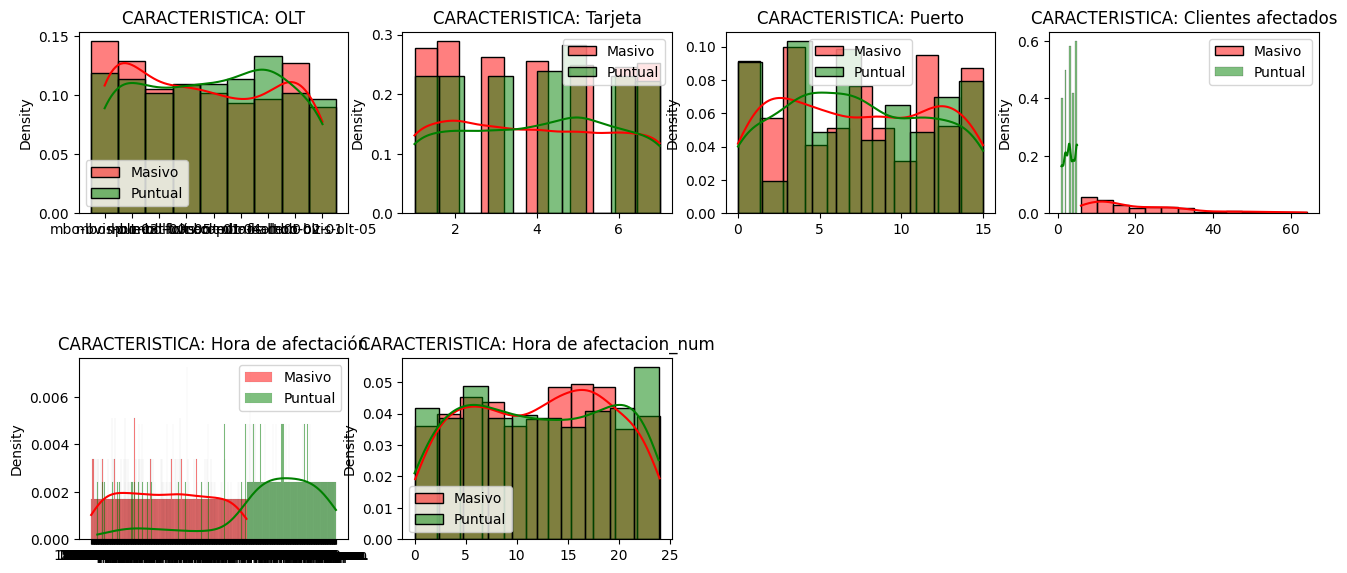

In [ ]:
# Representamos gráficamente las características
features = df.drop("CLASE", axis=1)

plt.figure(figsize=(16, 32))
gs = gridspec.GridSpec(8, 4)
gs.update(hspace=0.8)

for i, f in enumerate(features):
    ax = plt.subplot(gs[i])
    # Usando histplot para los casos donde CLASE == 'Masivo'
    sns.histplot(data=df[df["CLASE"] == 'Masivo'], x=f, kde=True, color="red", stat="density", label="Masivo", alpha=0.5)
    # Usando histplot para los casos donde CLASE == 'Puntual'
    sns.histplot(data=df[df["CLASE"] == 'Puntual'], x=f, kde=True, color="green", stat="density", label="Puntual", alpha=0.5)
    ax.set_xlabel('')
    ax.set_title(f"CARACTERISTICA: {f}")
    ax.legend()

plt.show()

# COMO PODEMOS VER EN LA GRAFICA DE ARRIBA LAS CARACTERISTICAS MAS DETERMINANTES, ES DECIR LAS QUE MAS SEPARAN LAS CLASES SON LAS CARACTERISTICAS DE
# "CLIENTES AFECTADOS" Y "HORA DE AFECTACION" , DICHAS CARACTERISTICAS SEPARAN LO MEJOR POSIBLE AMBAS CLASES Y SIRVEN PARA CLASIFICAR MEJOR ENTRE UN MASIVO Y UN CASO PUNTUAL

AHORA GRAFICAREMOS LAS CARACTERISTICAS MAS DETERMINANTES DEL CONJUNTO DE DATOS.

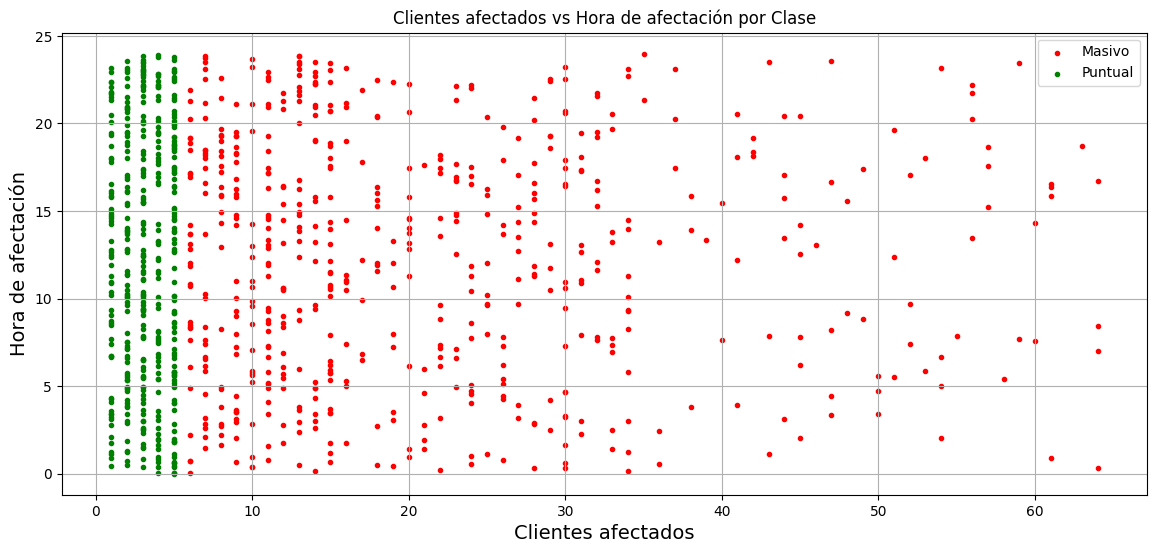

In [ ]:
# Importar numpy para manejar NaN si es necesario

# Representación gráfica de dos características con la libreria matplolit
plt.figure(figsize=(14, 6))
plt.scatter(
    df["Clientes afectados"][df['CLASE'] == 'Masivo'], # Filtrar por 'Masivo'
    df["Hora de afectacion_num"][df['CLASE'] == 'Masivo'], # Utilizar la columna numérica para la hora
    c="r", marker=".", label='Masivo'
)
plt.scatter(
    df["Clientes afectados"][df['CLASE'] == 'Puntual'], # Filtrar por 'Puntual'
    df["Hora de afectacion_num"][df['CLASE'] == 'Puntual'], # Utilizar la columna numérica para la hora
    c="g", marker=".", label='Puntual'
)
plt.xlabel("Clientes afectados", fontsize=14)
plt.ylabel("Hora de afectación", fontsize=14)
plt.title("Clientes afectados vs Hora de afectación por Clase")
plt.legend()
plt.grid(True)
plt.show()

# COMO PODEMOS OBSERVAR EN LA GRAFICA ANTERIOR LAS CARACTERISTICAS PARA CLASIFICAR SE PUEDEN SEPARAR LINEALMENTE. POR ESO EL ALGORITMO DE MACHINE LEARNING A UTILIZAR ES SUPORT VECTOR MACHINE O SVM, tambien se puede utilizar regresion logistica pero por prevision utilizaremos svm ya que cuenta con los limites y sera mas preciso.

No es necesario utilizar red neuronal porque el conjunto de datos es linealmente separable. si utilizaramos una red neuronal para este problema de clasificacion seria como matar un mosquito con una bazuca.

# EMPEZEMOS CON SUPPORT VECTOR MACHINE

In [71]:
# Reducimos el conjunto de datos para representarlo gráficamente
X_train_reduced = X_train_prep[["num__Clientes afectados", "num__Tarjeta"]].copy()
# Corregido: X_val_reduced debe usar las mismas características que X_train_reduced para la predicción con el modelo ya entrenado.
X_val_reduced = X_val_prep[["num__Clientes afectados", "num__Tarjeta"]].copy()

In [47]:
X_train_reduced

,num__Clientes afectados,num__Tarjeta
253,-0.1875,-0.50
28,1.5000,0.75
459,1.3750,-0.25
818,-0.4375,-0.75
521,1.1875,0.75
...,...,...
653,1.0625,0.50
648,-0.1875,-0.50
173,0.8750,-0.75
753,-0.4375,-0.75


# AHORA EMPEZEMOS CON EL ALGORITMO SVM

In [59]:
from sklearn.svm import SVC

# SVM Large Margin Classification ES EL ALGORITMO QUE PREDICE EL LIMITE PARA DETERMINAR UNA FALLA MASIVA
svm_clf = SVC(kernel="linear", C=50)
svm_clf.fit(X_train_reduced, y_train)

SVC(C=50, kernel='linear')

# grafiquemos los limites de decision

In [67]:
def plot_svc_decision_boundary(svm_clf, xmin, xmax):
    w = svm_clf.coef_[0]
    b = svm_clf.intercept_[0]

    # Check if the decision boundary is vertical (w[1] is zero or very close to zero)
    if np.isclose(w[1], 0):
        if np.isclose(w[0], 0):
            # Both coefficients are zero, no meaningful boundary
            return
        # frontera del  limite vertical: x = -b/w[0]
        x_intercept = -b / w[0] # Corrected: b is already a scalar
        plt.plot([x_intercept, x_intercept], [plt.ylim()[0], plt.ylim()[1]], "k-", linewidth=2)

        # Calculate margin for vertical lines along the x-axis
        margin_x = 1 / np.abs(w[0]) if w[0] != 0 else float('inf')
        plt.plot([x_intercept + margin_x, x_intercept + margin_x], [plt.ylim()[0], plt.ylim()[1]], "k--", linewidth=2)
        plt.plot([x_intercept - margin_x, x_intercept - margin_x], [plt.ylim()[0], plt.ylim()[1]], "k--", linewidth=2)
    else:
        # Standard case: sloped line
        x0 = np.linspace(xmin, xmax, 200)
        decision_boundary = -w[0]/w[1] * x0 - b/w[1]

        # Margin offset in y-direction
        y_margin_offset = 1 / np.abs(w[1]) # Use absolute value to ensure correct visual margin direction
        gutter_up = decision_boundary + y_margin_offset
        gutter_down = decision_boundary - y_margin_offset

        plt.plot(x0, decision_boundary, "k-", linewidth=2)
        plt.plot(x0, gutter_up, "k--", linewidth=2)
        plt.plot(x0, gutter_down, "k--", linewidth=2)

    svs = svm_clf.support_vectors_
    plt.scatter(svs[:, 0], svs[:, 1], s=180, facecolors='#FFAAAA')

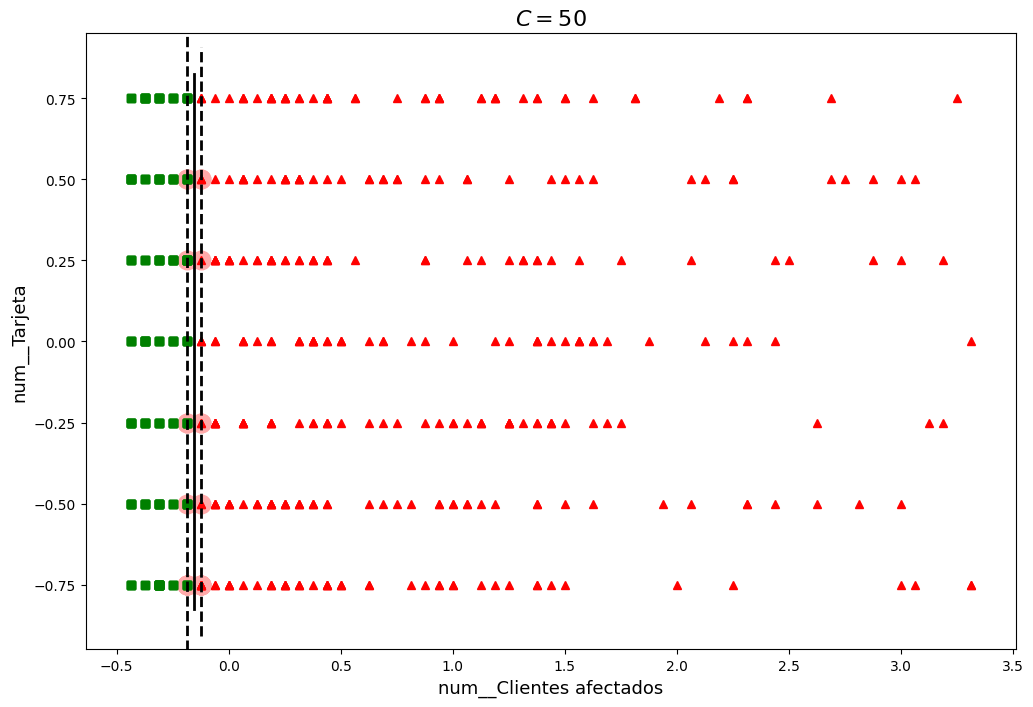

In [68]:
plt.figure(figsize=(12, 8))
plt.plot(X_train_reduced.values[:, 0][y_train=="Masivo"], X_train_reduced.values[:, 1][y_train=="Masivo"], "r^")
plt.plot(X_train_reduced.values[:, 0][y_train=="Puntual"], X_train_reduced.values[:, 1][y_train=="Puntual"], "gs")

# Adjust xmin and xmax to cover the range of 'num__Clientes afectados' from X_train_reduced
xmin_val = X_train_reduced['num__Clientes afectados'].min() - 0.1
xmax_val = X_train_reduced['num__Clientes afectados'].max() + 0.1
plot_svc_decision_boundary(svm_clf, xmin_val, xmax_val)

plt.title("$C = {}$".format(svm_clf.C), fontsize=16)

# Adjust axis limits to fit the data and decision boundary
plt.axis([
    X_train_reduced['num__Clientes afectados'].min() - 0.2,
    X_train_reduced['num__Clientes afectados'].max() + 0.2,
    X_train_reduced['num__Tarjeta'].min() - 0.2, # Corregido: usando 'num__Tarjeta'
    X_train_reduced['num__Tarjeta'].max() + 0.2  # Corregido: usando 'num__Tarjeta'
])

plt.xlabel("num__Clientes afectados", fontsize=13)
plt.ylabel("num__Tarjeta", fontsize=13) # Corregido: usando 'num__Tarjeta'
plt.show()

# Prediccion del conjunto de datos reducido

In [73]:
y_pred = svm_clf.predict(X_val_reduced)

# Prediccion de los casos masivos en el conjunto de datos reducido

In [78]:
print("F1 Score:", f1_score(y_pred, y_val, pos_label='Masivo'))

F1 Score: 1.0


# Prediccion del conjunto de datos reducido para casos Puntuales

In [79]:
print("F1 Score:", f1_score(y_pred, y_val, pos_label='Puntual'))

F1 Score: 1.0


100% DE ACIERTO EN PREDICION EN AMBAS CLASES PARA EL CONJUNTO REDUCIDO.

# CONSTRUIMOS UN PIPELINE PARA PODER LLAMAR AL ALGORITMO PREDICTIVO EN LOS DEMAS CONJUNTOS DE DATOS

In [80]:
svm_clf_sc = Pipeline([
        ("scaler", RobustScaler()),
        ("linear_svc", SVC(kernel="linear", C=50)),
    ])

svm_clf_sc.fit(X_train_reduced, y_train)

Pipeline(steps=[('scaler', RobustScaler()),
                ('linear_svc', SVC(C=50, kernel='linear'))])

# Probemos con el conjunto de datos completo

In [81]:
# Entrenamiento con todo el conjunto de datos
from sklearn.svm import SVC

svm_clf = SVC(kernel="linear", C=1)
svm_clf.fit(X_train_prep, y_train)

SVC(C=1, kernel='linear')

In [82]:
y_pred = svm_clf.predict(X_val_prep)

PREDICCION DEL ALGORITMO CON EL CONJUNTO DE DATOS DE VALIDACION , YA ENTRENADO PREVIAMENTE CON EL CONJUNTO DE DATOS DE PRUEBAS PARA CASOS MASIVOS UN TOTAL DE 96.5%

In [104]:
print("F1 Score:", f1_score(y_pred, y_val, pos_label='Masivo'))

F1 Score: 0.9649122807017544


PREDICCION DEL ALGORITMO EN EL CONJUNTO DE DATOS DE VALIDACION PARA LOS CASOS PUNTUALES TUVO UN 95.34% DE ACIERTO

In [103]:
print("F1 Score:", f1_score(y_pred, y_val, pos_label='Puntual'))

F1 Score: 0.9534883720930233


In [100]:
y_val.head(10)

,CLASE
228,Masivo
591,Masivo
107,Puntual
332,Masivo
568,Puntual
609,Puntual
441,Puntual
873,Masivo
411,Puntual
545,Puntual


In [102]:
y_pred


array(['Masivo', 'Masivo', 'Puntual', 'Masivo', 'Puntual', 'Puntual',
       'Puntual', 'Masivo', 'Puntual', 'Puntual', 'Masivo', 'Puntual',
       'Puntual', 'Puntual', 'Masivo', 'Puntual', 'Puntual', 'Puntual',
       'Puntual', 'Masivo', 'Masivo', 'Masivo', 'Masivo', 'Puntual',
       'Masivo', 'Masivo', 'Puntual', 'Puntual', 'Masivo', 'Masivo',
       'Masivo', 'Masivo', 'Masivo', 'Puntual', 'Puntual', 'Masivo',
       'Puntual', 'Puntual', 'Puntual', 'Puntual', 'Masivo', 'Masivo',
       'Masivo', 'Masivo', 'Masivo', 'Masivo', 'Puntual', 'Puntual',
       'Masivo', 'Puntual', 'Masivo', 'Masivo', 'Puntual', 'Masivo',
       'Puntual', 'Masivo', 'Puntual', 'Masivo', 'Masivo', 'Masivo',
       'Masivo', 'Masivo', 'Puntual', 'Masivo', 'Masivo', 'Puntual',
       'Puntual', 'Masivo', 'Masivo', 'Puntual', 'Puntual', 'Puntual',
       'Masivo', 'Masivo', 'Masivo', 'Puntual', 'Masivo', 'Puntual',
       'Puntual', 'Masivo', 'Masivo', 'Puntual', 'Masivo', 'Puntual',
       'Masivo', 'Masiv

# AHORA UTILIZAREMOS TEST SET QUE SON DATOS ETIQUETAS PERO QUE NUNCA ANTES AH VISTO EL ALGORITMO (NO SE ESPERA UN ACIERTO MUY GRANDE YA QUE EL DATASET INICIAL ES APENAS DE 1000 DATOS DE FALLAS.

In [105]:
print("F1 Score:", f1_score(y_pred, y_test, pos_label='Masivo'))

F1 Score: 0.5327510917030568


53.27% de precicion para casos masivos nuevos

In [107]:
print("F1 Score:", f1_score(y_pred, y_test, pos_label='Puntual'))

F1 Score: 0.3742690058479532


37.42% para casos puntuales nuevos

EL DATASET INICAL TIENE UN TAMAÑO DE 1000 DATOS , PARA QUE EL ALGORITMO SEA AUN MAS PRECISO SE REQUIEREN AL MENOS 20000 DATOS SERIA UN BUEN NUMERO PARA EMPEZAR